In [61]:
import numpy as np
import pyvista as pv
from pyau3d.files import TopFile, PartFile, ModeFile
from pyau3d.utils import PltFileUtils, NodFileUtils, AnimSmartStream, GrpFileUtils
from pyau3d.pv.loaders import GrpFileVTK
from pyau3d.pv.loader.grpfilevtk import _grp2pv
from pyau3d.pv.vtktool.pdata import polydata
import vtk
import matplotlib.pyplot as plt
from matplotlib import cm, ticker
from pyau3d.constants import Constants
from scipy.signal import hilbert
# Enable interactive backend
# %matplotlib widget

In [62]:


# specify group for animation file
# group = 2 corresponds to cylinder wall - could double check in .an02 file
RE = 60
Mach = 0.2
mesh_ver = 3
GROUP = 2
Mesh = 765960
ianimgrp = GROUP

 
# cfd_dir = f"/home/ahf25/CFD_2d_cylinder_all/Unsteady/M{Mach}/v{mesh_ver}_mesh/2d_cylinder_{Mesh}_Re{RE}_unsteady"

cfd_dir = f"/mnt/data1/ahf25/run4/2d_cylinder_{Mesh}_Re{RE}_unsteady"

nod_file = f"cylinder.nod"
plt_file = "cylinder.plt"
grp_file =f"cylinder.grp{GROUP:02}"
an_file = f"cylinder.an{GROUP:02}"
part_file = "cylinder.part"
top_file = "cylinder.top"

# specify file paths

path2nod = cfd_dir + "/" + nod_file
path2plt = cfd_dir  + "/" +  plt_file
path2grp = cfd_dir  + "/" +  grp_file
path2an = cfd_dir  + "/" +  an_file
path2part = cfd_dir  + "/" +  part_file
path2top = cfd_dir  + "/" +  top_file
 
mesh = PltFileUtils(path2plt)
nod = NodFileUtils(path2nod)
grp = GrpFileUtils(path2grp,GROUP)
groupfile = GrpFileVTK(path2grp,GROUP)
anim_vars = nod.ivars[GROUP - 1]
part_file = PartFile(path2part)
top = TopFile(path2top)

anim = AnimSmartStream(
    path2an,
    anim_vars=anim_vars,
    part=part_file,
    grp=grp
)

In [63]:
def area_normals_pv(coord, ifac3=None, ifac4=None):
    """
    Returns a pyvista.PolyData object with point normals scaled by the area of adjacent faces.
    Supports mixed triangle/quad surface meshes.

    Args:
        coord  : (N, 3) array of mesh point coordinates
        ifac3  : (M3, 3) array of triangle connectivity (zero-based), or None
        ifac4  : (M4, 4) array of quad connectivity (zero-based), or None

    Returns:
        pdata  : pyvista.PolyData with 'anor' point data field = area-weighted normals
    """
    import pyvista as pv

    face_blocks = []
    nfac3 = 0
    if ifac3 is not None and len(ifac3) > 0:
        ifac3 = np.asarray(ifac3)
        nfac3 = len(ifac3)
        face_blocks.append(np.hstack([np.full((nfac3, 1), 3), ifac3]))
    if ifac4 is not None and len(ifac4) > 0:
        ifac4 = np.asarray(ifac4)
        nfac4 = len(ifac4)
        face_blocks.append(np.hstack([np.full((nfac4, 1), 4), ifac4]))

    if not face_blocks:
        raise ValueError("At least one of ifac3 or ifac4 must be provided.")

    faces = np.vstack(face_blocks).flatten()
    pdata = pv.PolyData(coord, faces)

    # compute face areas — works for both tris and quads
    pdata = pdata.compute_cell_sizes(length=False, volume=False)
    face_areas = pdata['Area']   # ordered: tris first, then quads

    # accumulate area / n_verts at each point
    points_area = np.zeros(len(coord))
    if ifac3 is not None and len(ifac3) > 0:
        np.add.at(points_area, ifac3, face_areas[:nfac3, np.newaxis] / 3.0)
    if ifac4 is not None and len(ifac4) > 0:
        np.add.at(points_area, ifac4, face_areas[nfac3:, np.newaxis] / 4.0)

    # scale point normals by accumulated area
    pdata['anor'] = -pdata.point_normals * points_area[:, np.newaxis]

    return pdata

In [64]:
# compute surface area normals
blade = area_normals_pv(grp.coords, grp.icon3, grp.icon4)

# define delta t (for the solver)
deltat = top["dtstr"] / Constants()["u"]

# define delta_t per frame IMPORTANT
frame_rate = 50 # output rate of animation  e.g frame_rate = 10 referes to 1 output per 10 iterations
deltat_frame = deltat * frame_rate # delta t between each frame


force = []

# define parameters related to frames that captured in animation
start = 1 # start of frame
end = anim.nframes  # end of frame
interval = 1

frames = np.arange(start,end,interval)

force = []


for frame in frames:
    x = grp.coords[:,0]
    y = grp.coords[:,1]
    z = grp.coords[:,2]
 
    locp = np.searchsorted(nod.ivars[ianimgrp - 1],9)
    variables = np.arange(nod.nvars[ianimgrp - 1])
 
    data = anim.read_frame(frame,variables, )#redim = True,)
 
    blade['p'] = data[:, locp] * 10000
    blade['F'] = blade['p'][:] * np.dot(blade['anor'],[0,1,0]) # compute lift force area normal * y_unit vector
 
    Force = np.sum(blade['F'], axis = 0)
    force += [Force]

force = np.array(force)
t = np.arange(start,end,interval) * deltat_frame 

In [65]:
U_inf = 34.02626486*2 # farfield velocity (m/s)
rho_inf = 1.60E-05 # farfield density (kg/m^3)
span         = 0.1                        # span (m)
D            = 1
surface_area = span * D            # D × span = 1×1 m²

Envelope growth rate σ: -0.019


/tmp/ipykernel_510235/3096729901.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


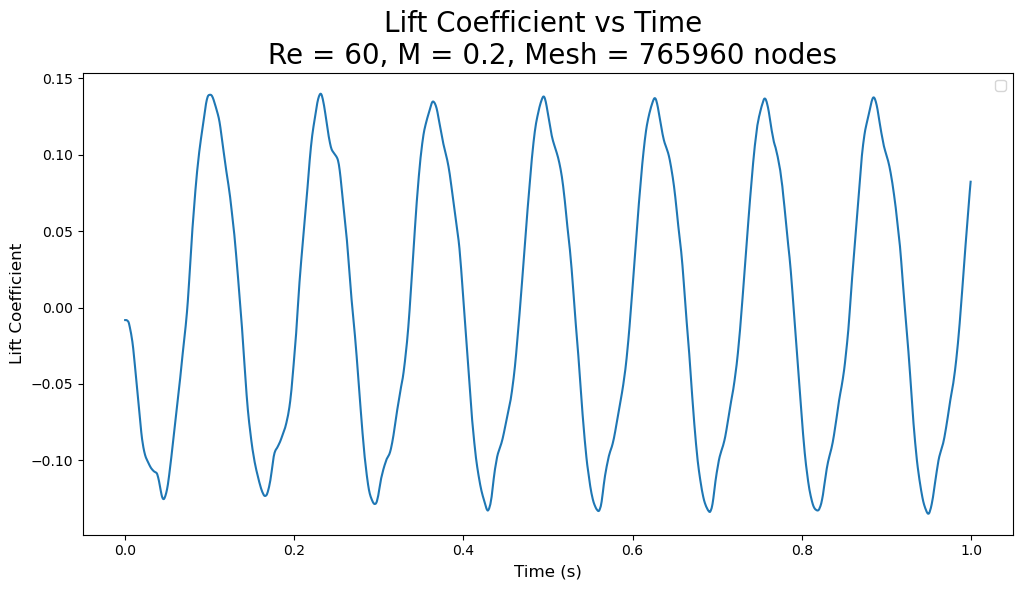

Check the final time should match: number of iterations * deltat (au3d)


In [71]:
CL = force / (0.5 * rho_inf * U_inf **2 * surface_area)
plt.figure(figsize=(12, 6))
plt.plot(t, CL)
plt.title(f"Lift Coefficient vs Time \n Re = {RE}, M = {Mach}, Mesh = {Mesh} nodes", fontsize = 20)
plt.xlabel("Time (s)", fontsize = 12)
plt.ylabel("Lift Coefficient", fontsize = 12)

# np.savetxt(f'../../data/Re{RE}/au3d_unsteady_Re{RE}_cl.csv', (t,CL), delimiter=',')

# to obtain growth rate of CL
# extract amplitude envelope by hilbert transform (use full signal to avoid edge effects)
analytic_signal = hilbert(CL - np.mean(CL))
envelope = np.abs(analytic_signal)
log_env = np.log(envelope)

# --- only use data after 1s (1000 data points) for the exponential fit ---
n_skip = 0  # number of points corresponding to the first 1s
t_fit = t[n_skip:]
log_env_fit = log_env[n_skip:]

# Fit exponential to the envelope (using only post-1s data)
coeffs = np.polyfit(t_fit, log_env_fit, deg=1)
growth_rate = coeffs[0]   # σ in e^(σt)
print(f"Envelope growth rate σ: {growth_rate:.3f}")
A = np.exp(coeffs[1])            # amplitude at t=0 (extrapolated from the fit)

exp_fit = A * np.exp(growth_rate * t)

# plt.plot(t, exp_fit + np.mean(CL))

# mark where the fit window starts
# plt.axvline(t[n_skip], color='gray', linestyle=':', alpha=0.7, label="Fit start (t=1s)")

plt.legend(fontsize=10)

# plt.annotate(f"Growth rate: {growth_rate:.3f} /s",
#              xy=(0.98, 0.95), xycoords='axes fraction',
#              ha='right', va='top', fontsize = 12,
#              bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))

plt.savefig("unsteady_cl_plot")
plt.show()

print("Check the final time should match: number of iterations * deltat (au3d)")

Envelope growth rate σ: -0.000


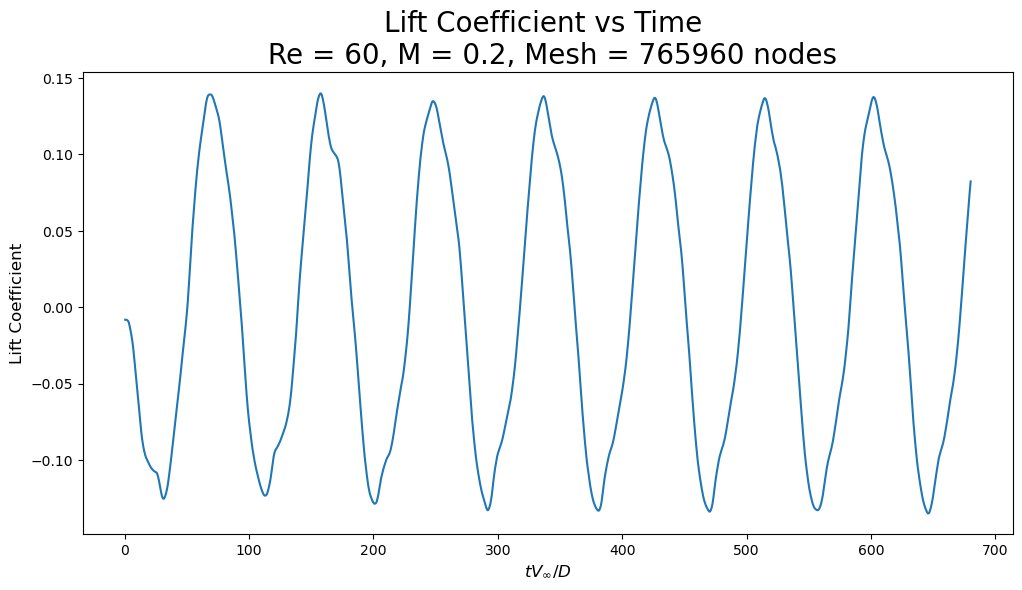

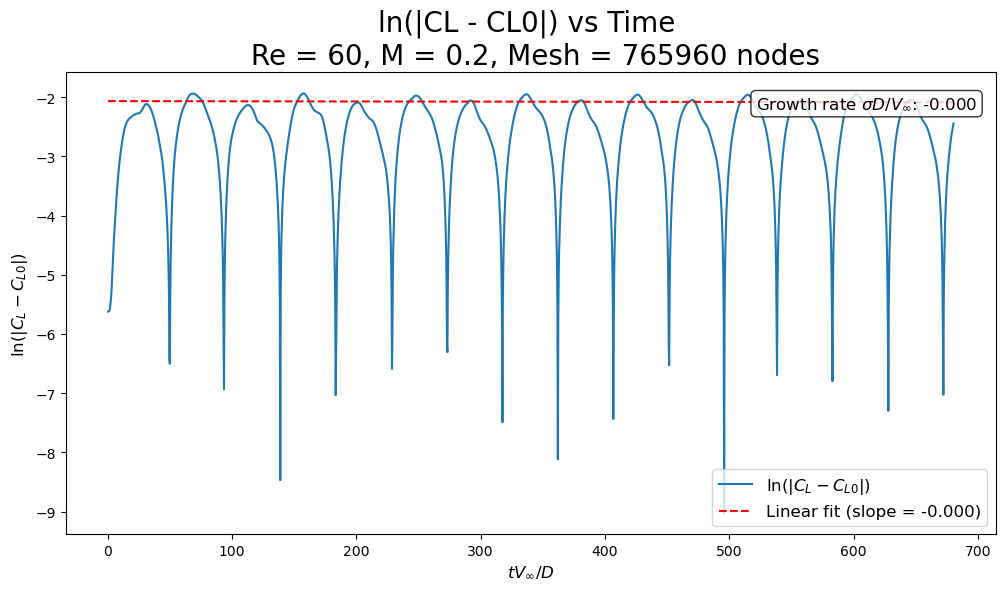

Check the final time should match: number of iterations * deltat (au3d)


In [67]:
# nondimensional time
t_nondim = t * U_inf / surface_area

# --- CL vs time plot ---
plt.figure(figsize=(12, 6))
plt.plot(t_nondim, CL)
plt.title(f"Lift Coefficient vs Time \n Re = {RE}, M = {Mach}, Mesh = {Mesh} nodes", fontsize = 20)
plt.xlabel(r"$t V_\infty / D$", fontsize = 12)
plt.ylabel("Lift Coefficient", fontsize = 12)

CL0 = np.mean(CL)

analytic_signal = hilbert(CL - CL0)
envelope = np.abs(analytic_signal)

log_env = np.log(envelope)
coeffs = np.polyfit(t_nondim, log_env, deg=1)   # <-- fit against nondimensional time
growth_rate = coeffs[0]
print(f"Envelope growth rate σ: {growth_rate:.3f}")
A = np.exp(coeffs[1])

exp_fit = A * np.exp(growth_rate * t_nondim)

# plt.savefig("unsteady_cl_plot")
plt.show()

# --- ln(|CL - CL0|) vs time plot ---
log_abs_dev = np.log(np.abs(CL - CL0))

plt.figure(figsize=(12, 6))
plt.plot(t_nondim, log_abs_dev, label=r"$\ln(|C_L - C_{L0}|)$")
plt.plot(t_nondim, coeffs[0] * t_nondim + coeffs[1], '--', color='red',
         label=f"Linear fit (slope = {growth_rate:.3f})")

plt.title(f"ln(|CL - CL0|) vs Time \n Re = {RE}, M = {Mach}, Mesh = {Mesh} nodes", fontsize=20)
plt.xlabel(r"$t V_\infty / D$", fontsize=12)
plt.ylabel(r"$\ln(|C_L - C_{L0}|)$", fontsize=12)
plt.legend(fontsize=12, loc='lower right')

plt.annotate(rf"Growth rate $\sigma D/V_\infty$: {growth_rate:.3f}",
             xy=(0.98, 0.95), xycoords='axes fraction',
             ha='right', va='top', fontsize = 12,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))

plt.savefig("unsteady_cl_log_plot")
plt.show()

print("Check the final time should match: number of iterations * deltat (au3d)")

Oscillation frequency: 8.004 Hz 


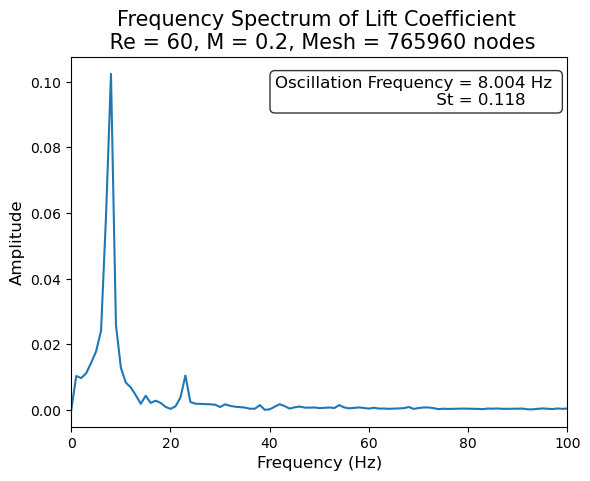

In [68]:
CL_fluctuation = CL - np.mean(CL)

N = len(CL_fluctuation)
dt = t[1] - t[0]

freqs = np.fft.rfftfreq(N, d=dt)
fft_vals = np.fft.rfft(CL_fluctuation)
amplitude = np.abs(fft_vals) * 2 / N
target_frequency = freqs[np.argmax(amplitude)]
strohaul = target_frequency * D / U_inf


plt.figure()
plt.plot(freqs, amplitude)
plt.title(f"Frequency Spectrum of Lift Coefficient \n Re = {RE}, M = {Mach}, Mesh = {Mesh} nodes", fontsize = 15)
plt.xlabel("Frequency (Hz)", fontsize = 12)
plt.ylabel("Amplitude",fontsize = 12)
plt.xlim(0,100)
# np.savetxt(f'../../data/Re{RE}/au3d_unsteady_Re{RE}_cl_fft.csv', (freqs, amplitude), delimiter=',')

plt.annotate(f"Oscillation Frequency = {target_frequency:.3f} Hz \n St = {strohaul:.3f}      ",
             xy=(0.98, 0.95), xycoords='axes fraction',
             ha='right', va='top', fontsize = 12,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8))
plt.savefig("unsteady_cl_fft")
print(f"Oscillation frequency: {target_frequency:.3f} Hz ")